# 预处理

In [ ]:
# ===============================
# 数据预处理 (新版，CLC 不再重复进入)
# ===============================
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import joblib
import json
import os

print("--- 数据预处理开始 ---")

# 路径配置
DATA_PATH = r"E:\Project-yqr\new\data\BD_filled_select.csv"
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
os.makedirs(PREPROCESS_DIR, exist_ok=True)

# 1. 读取数据
df = pd.read_csv(DATA_PATH)
print(f"原始数据形状: {df.shape}")

# ⚠️ 保留 ID
if "ID" not in df.columns:
    raise ValueError("输入数据里没有 ID 列，请检查源文件！")

# 2. 协变量 & 目标变量
X_raw = df.iloc[:, 5:23].copy()
if "CLC" in X_raw.columns:
    X_raw = X_raw.drop(columns=["CLC"])

y_BD = df["BD"]
y_CV = df["CV"]

# 3. KNN 缺失值填补
print("KNN 缺失值填补中...")
imputer = KNNImputer(n_neighbors=5, weights="distance")
X_imputed = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed, columns=X_raw.columns, index=df.index)
joblib.dump(imputer, os.path.join(PREPROCESS_DIR, "knn_imputer.joblib"))

# 4. 合并目标变量（这里同步缩减 ID）
df_processed = pd.concat([df["ID"], X_imputed, df["CLC"], y_BD, y_CV], axis=1).dropna(subset=["BD", "CV"])
print(f"缺失剔除后数据形状: {df_processed.shape}")

# 5. 相关性筛选（仅数值特征，不含 CLC）
X_for_corr = df_processed[X_imputed.columns]
corr_matrix = X_for_corr.corr()
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            to_drop.add(corr_matrix.columns[i])
X_filtered = X_for_corr.drop(columns=list(to_drop))
final_columns = X_filtered.columns.tolist()
with open(os.path.join(PREPROCESS_DIR, "final_feature_columns.json"), "w") as f:
    json.dump(final_columns, f)

# 6. 标准化数值型特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
X_scaled = pd.DataFrame(X_scaled, columns=X_filtered.columns, index=df_processed.index)
joblib.dump(scaler, os.path.join(PREPROCESS_DIR, "standard_scaler.joblib"))

# 7. 处理 CLC（分类变量）
CLC_int = df_processed["CLC"].astype(int)  # 保留索引
CLC_onehot = pd.get_dummies(CLC_int, prefix="CLC")

# 8. ID 自动对齐（按 df_processed 索引）
ID_col_aligned = df_processed["ID"]

# ⚠️ 索引一致性检查
assert len(X_scaled) == len(CLC_int) == len(ID_col_aligned), (
    f"行数不一致：X_scaled={len(X_scaled)}, CLC_int={len(CLC_int)}, ID={len(ID_col_aligned)}"
)

# 9. 生成两份输入（带 ID）
X_for_tree = pd.concat([ID_col_aligned.reset_index(drop=True), X_scaled.reset_index(drop=True), CLC_int.reset_index(drop=True).rename("CLC_int")], axis=1)
X_for_cubist = pd.concat([ID_col_aligned.reset_index(drop=True), X_scaled.reset_index(drop=True), CLC_onehot.reset_index(drop=True)], axis=1)

# 保存到本地
X_for_tree.to_csv(os.path.join(PREPROCESS_DIR, "X_for_tree.csv"), index=False)
X_for_cubist.to_csv(os.path.join(PREPROCESS_DIR, "X_for_cubist.csv"), index=False)
df_processed[["ID", "BD", "CV"]].to_csv(os.path.join(PREPROCESS_DIR, "targets.csv"), index=False)

print("✅ 预处理完成，已保存以下文件：")
print(" - X_for_tree.csv（给 RF/XGB 用）")
print(" - X_for_cubist.csv（给 Cubist 用）")
print(" - targets.csv（目标变量）")
print(" - knn_imputer.joblib, standard_scaler.joblib, final_feature_columns.json")


--- 数据预处理开始 ---
原始数据形状: (27793, 25)
KNN 缺失值填补中...
缺失剔除后数据形状: (6052, 20)
✅ 预处理完成，已保存以下文件：
 - X_for_tree.csv（给 RF/XGB 用）
 - X_for_cubist.csv（给 Cubist 用）
 - targets.csv（目标变量）
 - knn_imputer.joblib, standard_scaler.joblib, final_feature_columns.json


# Cubist

## BD

### 训练模型

In [5]:
# ===============================
# Cubist 训练 + 查看结果（二合一）
# 读取预处理产物：X_for_cubist.csv / targets.csv
# 调 Optuna，训练最终模型，打印评估指标并保存模型
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import optuna

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_cubist.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")

MODEL_DIR = r"E:\Project-yqr\828update\BD\model"
DB_DIR = r"E:\Project-yqr\828update\BD\database"
MODEL_PATH = os.path.join(MODEL_DIR, "cubist_bd.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, 'cubist_bd_study.db')}"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

SEED = 66
TEST_SIZE = 0.2
CV_FOLDS = 10
OPTUNA_TIMEOUT = 600  # 秒

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)          # 数值标准化 + CLC one-hot（预处理脚本已完成）
y = pd.read_csv(Y_PATH)["BD"]    # 目标：BD

print(f"X 形状: {X.shape}")
print(f"y 长度: {len(y)}")

# ---------- 划分训练/测试 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=100
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ---------- Cubist 导入 ----------
try:
    from cubist import Cubist
except ImportError:
    print("❌ 未安装 cubist-python，请先: pip install cubist-python")
    raise SystemExit

# ---------- Optuna 目标函数 ----------
def objective(trial):
    params = {
        "n_committees": trial.suggest_int("n_committees", 40, 100),
        "n_rules": trial.suggest_int("n_rules", 50, 75),
        "neighbors": trial.suggest_int("neighbors", 8, 9),
        "random_state": SEED,
    }
    model = Cubist(**params)

    scorer = make_scorer(mean_squared_error, greater_is_better=False)
    try:
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=CV_FOLDS, scoring=scorer, n_jobs=-1
        )
        rmse = np.sqrt(-cv_scores.mean())
        return rmse
    except Exception as e:
        print(f"Trial {trial.number} 出错: {e}")
        return float("inf")

# ---------- Optuna 搜索 ----------
study = optuna.create_study(
    study_name="cubist_regression_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize",
)
print("\n--- 开始 Optuna 调参 ---")
study.optimize(objective, timeout=OPTUNA_TIMEOUT)
print("--- Optuna 完成 ---")
print("最佳参数: ", study.best_params)

# ---------- 训练最终模型 ----------
best_params = {**study.best_params, "random_state": SEED}
final_model = Cubist(**best_params)
final_model.fit(X_train, y_train)

# ---------- 保存模型 ----------
joblib.dump(final_model, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ---------- 查看结果（训练/测试评估） ----------
y_pred_tr = final_model.predict(X_train)
y_pred_te = final_model.predict(X_test)

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_tr)),
    "Train_MAE": mean_absolute_error(y_train, y_pred_tr),
    "Train_R2": r2_score(y_train, y_pred_tr),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_te),
    "Test_R2": r2_score(y_test, y_pred_te),
}
print("\n--- 模型评估（直接查看结果） ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


X 形状: (6052, 48)
y 长度: 6052
训练集: (4841, 48), 测试集: (1211, 48)


[I 2025-08-29 16:57:00,978] A new study created in RDB with name: cubist_regression_hpo



--- 开始 Optuna 调参 ---


[I 2025-08-29 16:57:41,840] Trial 0 finished with value: 0.19522912023140662 and parameters: {'n_committees': 63, 'n_rules': 66, 'neighbors': 9}. Best is trial 0 with value: 0.19522912023140662.
[I 2025-08-29 16:58:19,126] Trial 1 finished with value: 0.1955733869910901 and parameters: {'n_committees': 73, 'n_rules': 56, 'neighbors': 8}. Best is trial 0 with value: 0.19522912023140662.
[I 2025-08-29 16:58:53,553] Trial 2 finished with value: 0.19557067096842645 and parameters: {'n_committees': 68, 'n_rules': 65, 'neighbors': 8}. Best is trial 0 with value: 0.19522912023140662.
[I 2025-08-29 16:59:32,805] Trial 3 finished with value: 0.19515710325986105 and parameters: {'n_committees': 79, 'n_rules': 66, 'neighbors': 9}. Best is trial 3 with value: 0.19515710325986105.
[I 2025-08-29 17:00:14,028] Trial 4 finished with value: 0.195160448604358 and parameters: {'n_committees': 78, 'n_rules': 70, 'neighbors': 9}. Best is trial 3 with value: 0.19515710325986105.
[I 2025-08-29 17:00:51,894] 

--- Optuna 完成 ---
最佳参数:  {'n_committees': 99, 'n_rules': 62, 'neighbors': 9}
✅ 模型已保存: E:\Project-yqr\828update\BD\model\cubist_bd.joblib

--- 模型评估（直接查看结果） ---
Train_RMSE: 0.1367
Train_MAE: 0.1043
Train_R2: 0.8407
Test_RMSE: 0.1956
Test_MAE: 0.1493
Test_R2: 0.6757


### 画图

✅ 已加载模型: E:\Project-yqr\828update\BD\model\cubist_bd.joblib

--- 评估指标 ---
Train: RMSE=0.1367, MAE=0.1043, R2=0.8407
Test : RMSE=0.1956, MAE=0.1493, R2=0.6757


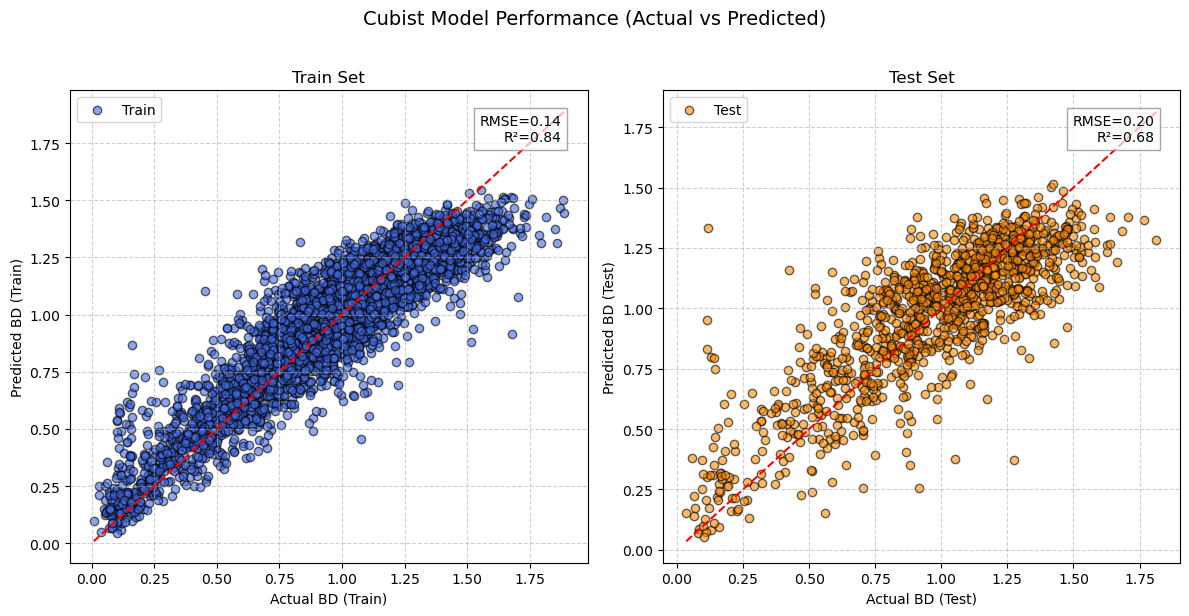

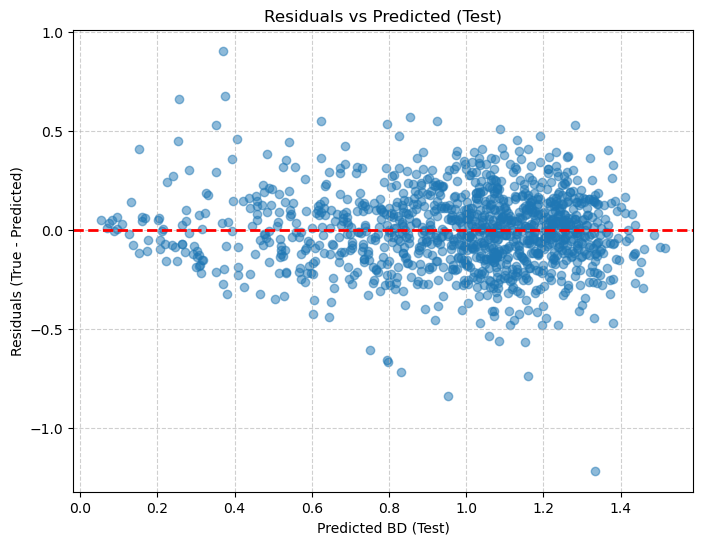

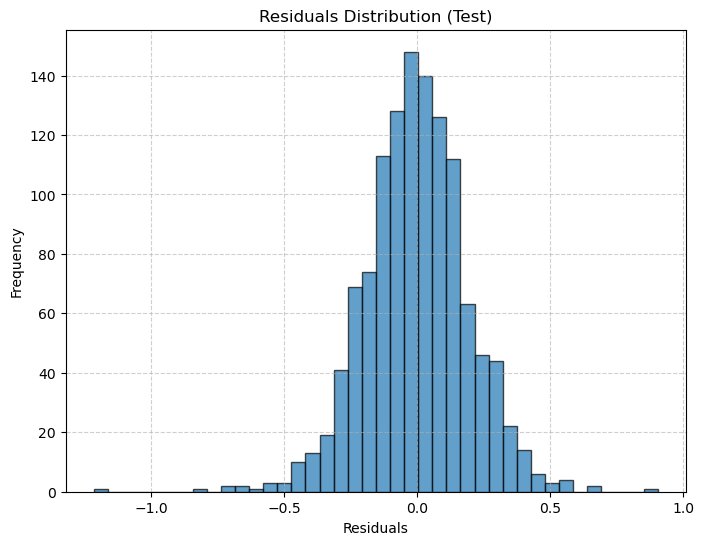


--- 特征重要性 ---


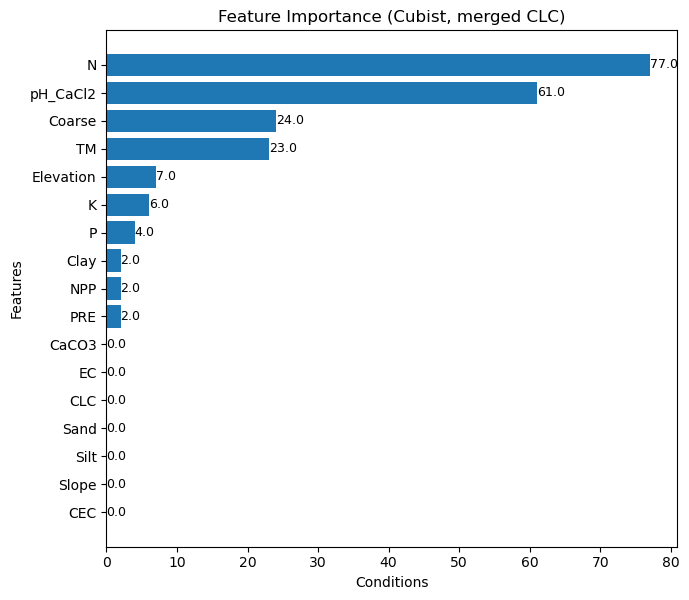

In [13]:
# ===============================
# Cubist 绘图（单独脚本）
# 加载模型 + 同样划分（random_state=100）+ 画三类图 + 特征重要性
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_cubist.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_PATH = r"E:\Project-yqr\828update\BD\model\cubist_bd.joblib"

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)["BD"]

# 保证和训练脚本一致的划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)

# ---------- 加载模型 ----------
try:
    from cubist import Cubist
except ImportError:
    print("❌ 未安装 cubist-python，请先: pip install cubist-python")
    raise SystemExit

try:
    model = joblib.load(MODEL_PATH)
    print(f"✅ 已加载模型: {MODEL_PATH}")
except Exception as e:
    print(f"❌ 加载模型失败: {e}")
    raise SystemExit

# ---------- 预测 & 评估 ----------
y_pred_tr = model.predict(X_train)
y_pred_te = model.predict(X_test)

tr_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
tr_mae  = mean_absolute_error(y_train, y_pred_tr)
tr_r2   = r2_score(y_train, y_pred_tr)

te_rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
te_mae  = mean_absolute_error(y_test, y_pred_te)
te_r2   = r2_score(y_test, y_pred_te)

print("\n--- 评估指标 ---")
print(f"Train: RMSE={tr_rmse:.4f}, MAE={tr_mae:.4f}, R2={tr_r2:.4f}")
print(f"Test : RMSE={te_rmse:.4f}, MAE={te_mae:.4f}, R2={te_r2:.4f}")

# ---------- 图1改版：真实 vs 预测（训练/测试 分开） ----------
# ---------- 图1改版：真实 vs 预测（训练/测试 分开） ----------
plt.figure(figsize=(12, 6))

# --- Train ---
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_tr, alpha=0.6, c="royalblue", edgecolor="k", label="Train")
minv = min(y_train.min(), y_pred_tr.min())
maxv = max(y_train.max(), y_pred_tr.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel("Actual BD (Train)")
plt.ylabel("Predicted BD (Train)")
plt.title("Train Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# --- 右上角指标 ---
plt.text(
    0.95, 0.95,
    f"RMSE={tr_rmse:.2f}\nR²={tr_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

# --- Test ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_te, alpha=0.6, c="darkorange", edgecolor="k", label="Test")
minv = min(y_test.min(), y_pred_te.min())
maxv = max(y_test.max(), y_pred_te.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel("Actual BD (Test)")
plt.ylabel("Predicted BD (Test)")
plt.title("Test Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# --- 右上角指标 ---
plt.text(
    0.95, 0.95,
    f"RMSE={te_rmse:.2f}\nR²={te_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.suptitle("Cubist Model Performance (Actual vs Predicted)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ---------- 图2：残差 vs 预测（测试集） ----------
resid_te = y_test - y_pred_te
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_te, resid_te, alpha=0.5)
plt.axhline(0, color="r", linestyle="--", lw=2)
plt.xlabel("Predicted BD (Test)")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---------- 图3：残差分布（测试集） ----------
plt.figure(figsize=(8, 6))
plt.hist(resid_te, bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---------- 图4：特征重要性（合并 CLC_xx） ----------
print("\n--- 特征重要性 ---")
try:
    fi = model.feature_importances_
    if not {"Variable", "Conditions"}.issubset(fi.columns):
        raise ValueError("feature_importances_ 缺少必要列（Variable, Conditions）")

    # 合并所有 CLC_xx → CLC
    fi_grouped = fi.copy()
    fi_grouped.loc[fi_grouped["Variable"].str.startswith("CLC_"), "Variable"] = "CLC"
    fi_grouped = fi_grouped.groupby("Variable", as_index=False)["Conditions"].sum()
    fi_grouped = fi_grouped.sort_values("Conditions", ascending=False)

    # 画图
    plt.figure(figsize=(7, max(3, len(fi_grouped) * 0.3 + 1)))
    plt.barh(fi_grouped["Variable"], fi_grouped["Conditions"])
    plt.xlabel("Conditions")
    plt.ylabel("Features")
    plt.title("Feature Importance (Cubist, merged CLC)")
    plt.gca().invert_yaxis()
    for i, v in enumerate(fi_grouped["Conditions"]):
        plt.text(v, i, f"{v:.1f}", ha="left", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ 特征重要性绘制失败: {e}")



## CV

### 训练模型

In [6]:
# ===============================
# Cubist 训练 + 查看结果（二合一）
# 读取预处理产物：X_for_cubist.csv / targets.csv
# 调 Optuna，训练最终模型，打印评估指标并保存模型
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import optuna

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_cubist.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")

MODEL_DIR = r"E:\Project-yqr\828update\BD\model"
DB_DIR = r"E:\Project-yqr\828update\BD\database"
MODEL_PATH = os.path.join(MODEL_DIR, "cubist_cv.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, 'cubist_cv_study.db')}"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

SEED = 66
TEST_SIZE = 0.2
CV_FOLDS = 10
OPTUNA_TIMEOUT = 600  # 秒

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)          # 数值标准化 + CLC one-hot（预处理脚本已完成）
y = pd.read_csv(Y_PATH)["CV"]    # 目标：CV

print(f"X 形状: {X.shape}")
print(f"y 长度: {len(y)}")

# ---------- 划分训练/测试 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=100
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ---------- Cubist 导入 ----------
try:
    from cubist import Cubist
except ImportError:
    print("❌ 未安装 cubist-python，请先: pip install cubist-python")
    raise SystemExit

# ---------- Optuna 目标函数 ----------
def objective(trial):
    params = {
        "n_committees": trial.suggest_int("n_committees", 40, 100),
        "n_rules": trial.suggest_int("n_rules", 50, 75),
        "neighbors": trial.suggest_int("neighbors", 8, 9),
        "random_state": SEED,
    }
    model = Cubist(**params)

    scorer = make_scorer(mean_squared_error, greater_is_better=False)
    try:
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=CV_FOLDS, scoring=scorer, n_jobs=-1
        )
        rmse = np.sqrt(-cv_scores.mean())
        return rmse
    except Exception as e:
        print(f"Trial {trial.number} 出错: {e}")
        return float("inf")

# ---------- Optuna 搜索 ----------
study = optuna.create_study(
    study_name="cubist_regression_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize",
)
print("\n--- 开始 Optuna 调参 ---")
study.optimize(objective, timeout=OPTUNA_TIMEOUT)
print("--- Optuna 完成 ---")
print("最佳参数: ", study.best_params)

# ---------- 训练最终模型 ----------
best_params = {**study.best_params, "random_state": SEED}
final_model = Cubist(**best_params)
final_model.fit(X_train, y_train)

# ---------- 保存模型 ----------
joblib.dump(final_model, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ---------- 查看结果（训练/测试评估） ----------
y_pred_tr = final_model.predict(X_train)
y_pred_te = final_model.predict(X_test)

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_tr)),
    "Train_MAE": mean_absolute_error(y_train, y_pred_tr),
    "Train_R2": r2_score(y_train, y_pred_tr),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_te),
    "Test_R2": r2_score(y_test, y_pred_te),
}
print("\n--- 模型评估（直接查看结果） ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


X 形状: (6052, 48)
y 长度: 6052
训练集: (4841, 48), 测试集: (1211, 48)


[I 2025-08-29 17:07:40,462] A new study created in RDB with name: cubist_regression_hpo



--- 开始 Optuna 调参 ---


[I 2025-08-29 17:08:18,189] Trial 0 finished with value: 0.016036143901392446 and parameters: {'n_committees': 95, 'n_rules': 64, 'neighbors': 9}. Best is trial 0 with value: 0.016036143901392446.
[I 2025-08-29 17:08:44,957] Trial 1 finished with value: 0.016062680107367708 and parameters: {'n_committees': 58, 'n_rules': 70, 'neighbors': 9}. Best is trial 0 with value: 0.016036143901392446.
[I 2025-08-29 17:09:19,355] Trial 2 finished with value: 0.016046769950099914 and parameters: {'n_committees': 80, 'n_rules': 59, 'neighbors': 9}. Best is trial 0 with value: 0.016036143901392446.
[I 2025-08-29 17:09:52,759] Trial 3 finished with value: 0.01604604067621203 and parameters: {'n_committees': 77, 'n_rules': 51, 'neighbors': 9}. Best is trial 0 with value: 0.016036143901392446.
[I 2025-08-29 17:10:14,801] Trial 4 finished with value: 0.016025172047874996 and parameters: {'n_committees': 47, 'n_rules': 55, 'neighbors': 8}. Best is trial 4 with value: 0.016025172047874996.
[I 2025-08-29 17

--- Optuna 完成 ---
最佳参数:  {'n_committees': 42, 'n_rules': 67, 'neighbors': 8}
✅ 模型已保存: E:\Project-yqr\828update\BD\model\cubist_cv.joblib

--- 模型评估（直接查看结果） ---
Train_RMSE: 0.0092
Train_MAE: 0.0056
Train_R2: 0.9715
Test_RMSE: 0.0142
Test_MAE: 0.0087
Test_R2: 0.9268


### 画图

✅ 已加载模型: E:\Project-yqr\828update\BD\model\cubist_cv.joblib

--- 评估指标 ---
Train: RMSE=0.0092, MAE=0.0056, R2=0.9715
Test : RMSE=0.0142, MAE=0.0087, R2=0.9268


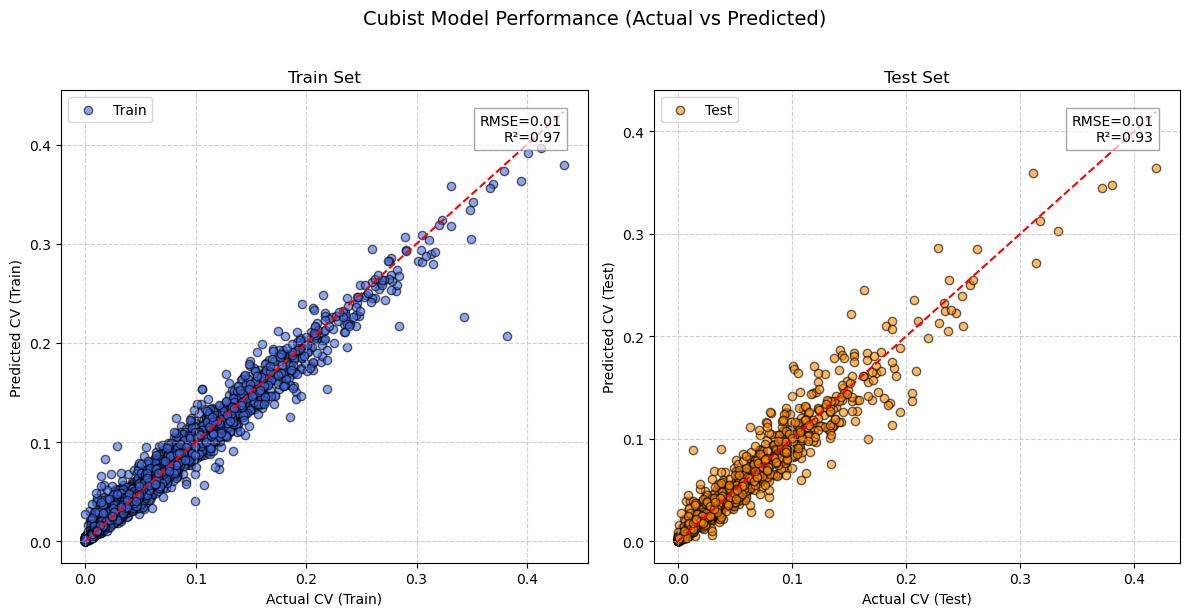

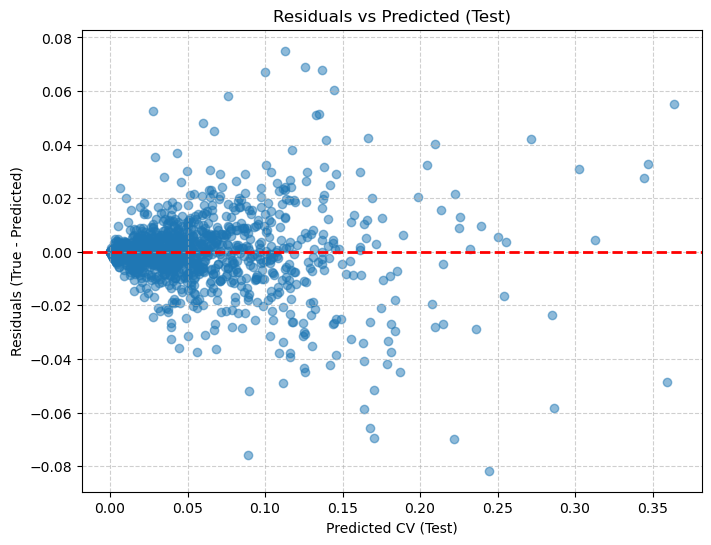

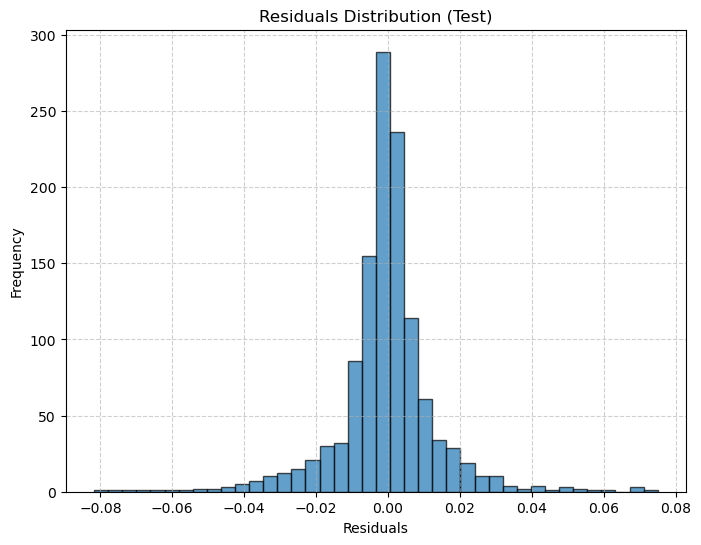


--- 特征重要性 ---


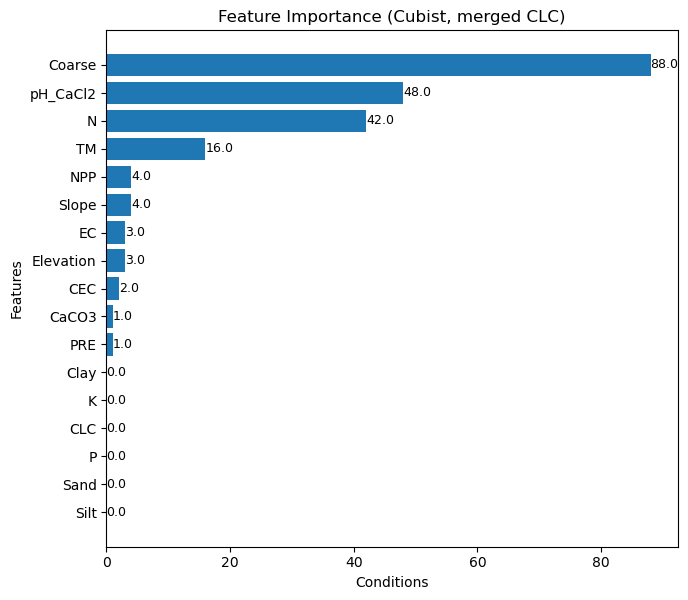

In [14]:
# ===============================
# Cubist 绘图（单独脚本）
# 加载模型 + 同样划分（random_state=100）+ 画三类图 + 特征重要性
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_cubist.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_PATH = r"E:\Project-yqr\828update\BD\model\cubist_cv.joblib"

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)["CV"]

# 保证和训练脚本一致的划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)

# ---------- 加载模型 ----------
try:
    from cubist import Cubist
except ImportError:
    print("❌ 未安装 cubist-python，请先: pip install cubist-python")
    raise SystemExit

try:
    model = joblib.load(MODEL_PATH)
    print(f"✅ 已加载模型: {MODEL_PATH}")
except Exception as e:
    print(f"❌ 加载模型失败: {e}")
    raise SystemExit

# ---------- 预测 & 评估 ----------
y_pred_tr = model.predict(X_train)
y_pred_te = model.predict(X_test)

tr_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
tr_mae  = mean_absolute_error(y_train, y_pred_tr)
tr_r2   = r2_score(y_train, y_pred_tr)

te_rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
te_mae  = mean_absolute_error(y_test, y_pred_te)
te_r2   = r2_score(y_test, y_pred_te)

print("\n--- 评估指标 ---")
print(f"Train: RMSE={tr_rmse:.4f}, MAE={tr_mae:.4f}, R2={tr_r2:.4f}")
print(f"Test : RMSE={te_rmse:.4f}, MAE={te_mae:.4f}, R2={te_r2:.4f}")

# ---------- 图1改版：真实 vs 预测（训练/测试 分开） ----------
# ---------- 图1改版：真实 vs 预测（训练/测试 分开） ----------
plt.figure(figsize=(12, 6))

# --- Train ---
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_tr, alpha=0.6, c="royalblue", edgecolor="k", label="Train")
minv = min(y_train.min(), y_pred_tr.min())
maxv = max(y_train.max(), y_pred_tr.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel("Actual CV (Train)")
plt.ylabel("Predicted CV (Train)")
plt.title("Train Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# --- 右上角指标 ---
plt.text(
    0.95, 0.95,
    f"RMSE={tr_rmse:.2f}\nR²={tr_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

# --- Test ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_te, alpha=0.6, c="darkorange", edgecolor="k", label="Test")
minv = min(y_test.min(), y_pred_te.min())
maxv = max(y_test.max(), y_pred_te.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel("Actual CV (Test)")
plt.ylabel("Predicted CV (Test)")
plt.title("Test Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# --- 右上角指标 ---
plt.text(
    0.95, 0.95,
    f"RMSE={te_rmse:.2f}\nR²={te_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.suptitle("Cubist Model Performance (Actual vs Predicted)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ---------- 图2：残差 vs 预测（测试集） ----------
resid_te = y_test - y_pred_te
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_te, resid_te, alpha=0.5)
plt.axhline(0, color="r", linestyle="--", lw=2)
plt.xlabel("Predicted CV (Test)")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---------- 图3：残差分布（测试集） ----------
plt.figure(figsize=(8, 6))
plt.hist(resid_te, bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---------- 图4：特征重要性（合并 CLC_xx） ----------
print("\n--- 特征重要性 ---")
try:
    fi = model.feature_importances_
    if not {"Variable", "Conditions"}.issubset(fi.columns):
        raise ValueError("feature_importances_ 缺少必要列（Variable, Conditions）")

    # 合并所有 CLC_xx → CLC
    fi_grouped = fi.copy()
    fi_grouped.loc[fi_grouped["Variable"].str.startswith("CLC_"), "Variable"] = "CLC"
    fi_grouped = fi_grouped.groupby("Variable", as_index=False)["Conditions"].sum()
    fi_grouped = fi_grouped.sort_values("Conditions", ascending=False)

    # 画图
    plt.figure(figsize=(7, max(3, len(fi_grouped) * 0.3 + 1)))
    plt.barh(fi_grouped["Variable"], fi_grouped["Conditions"])
    plt.xlabel("Conditions")
    plt.ylabel("Features")
    plt.title("Feature Importance (Cubist, merged CLC)")
    plt.gca().invert_yaxis()
    for i, v in enumerate(fi_grouped["Conditions"]):
        plt.text(v, i, f"{v:.1f}", ha="left", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ 特征重要性绘制失败: {e}")



# RF

## BD

### 训练模型

In [7]:
# ===============================
# Random Forest + Optuna (训练+结果)
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")   # 注意 RF 用的是 tree 版
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")

MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "BD"  # 或 "CV"
MODEL_PATH = os.path.join(MODEL_DIR, f"rf_{TARGET}.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'rf_{TARGET}_study.db')}"

SEED = 42
TEST_SIZE = 0.2
CV_FOLDS = 10
OPTUNA_TIMEOUT = 1200

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ---------- Optuna 目标函数 ----------
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1400, step=100),
        "max_depth": trial.suggest_int("max_depth", 10, 60, step=5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.6, 0.8, 1.0]),
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    scorer = make_scorer(mean_squared_error, greater_is_better=False)

    try:
        cv_scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring=scorer, n_jobs=-1)
        rmse = np.sqrt(-cv_scores.mean())
    except Exception as e:
        print(f"Trial {trial.number} 出错: {e}")
        return float("inf")
    return rmse

# ---------- Optuna 搜索 ----------
study_rf = optuna.create_study(
    study_name=f"rf_{TARGET}_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize"
)
print("\n--- 开始 Optuna 调参 (RF) ---")
study_rf.optimize(objective_rf, timeout=OPTUNA_TIMEOUT)
print("--- Optuna 完成 ---")
print("最佳参数: ", study_rf.best_params)

# ---------- 训练最终模型 ----------
final_model_rf = RandomForestRegressor(**study_rf.best_params, random_state=SEED, n_jobs=-1)
final_model_rf.fit(X_train, y_train)
joblib.dump(final_model_rf, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ---------- 查看结果 ----------
y_pred_tr = final_model_rf.predict(X_train)
y_pred_te = final_model_rf.predict(X_test)

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_tr)),
    "Train_MAE": mean_absolute_error(y_train, y_pred_tr),
    "Train_R2": r2_score(y_train, y_pred_tr),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_te),
    "Test_R2": r2_score(y_test, y_pred_te),
}
print("\n--- RF 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")




训练集: (4841, 17), 测试集: (1211, 17)


[I 2025-08-29 17:18:13,694] A new study created in RDB with name: rf_BD_hpo



--- 开始 Optuna 调参 (RF) ---


[I 2025-08-29 17:19:26,115] Trial 0 finished with value: 0.1939028743517409 and parameters: {'n_estimators': 1300, 'max_depth': 40, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.8}. Best is trial 0 with value: 0.1939028743517409.
[I 2025-08-29 17:19:50,854] Trial 1 finished with value: 0.19504511828461432 and parameters: {'n_estimators': 1100, 'max_depth': 40, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.1939028743517409.
[I 2025-08-29 17:20:03,984] Trial 2 finished with value: 0.19461619009906445 and parameters: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.1939028743517409.
[I 2025-08-29 17:21:14,235] Trial 3 finished with value: 0.19397879088391592 and parameters: {'n_estimators': 800, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 1.0}. Best is trial 0 with value: 0.19390287435174

--- Optuna 完成 ---
最佳参数:  {'n_estimators': 700, 'max_depth': 40, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.6}
✅ 模型已保存: E:\Project-yqr\828update\BD\model\rf_BD.joblib

--- RF 模型评估 ---
Train_RMSE: 0.1013
Train_MAE: 0.0743
Train_R2: 0.9126
Test_RMSE: 0.1898
Test_MAE: 0.1465
Test_R2: 0.6927


### 绘图

✅ 已加载模型: E:\Project-yqr\828update\BD\model\rf_BD.joblib

--- 评估指标 ---
Train: RMSE=0.1013, MAE=0.0743, R2=0.9126
Test : RMSE=0.1898, MAE=0.1465, R2=0.6927


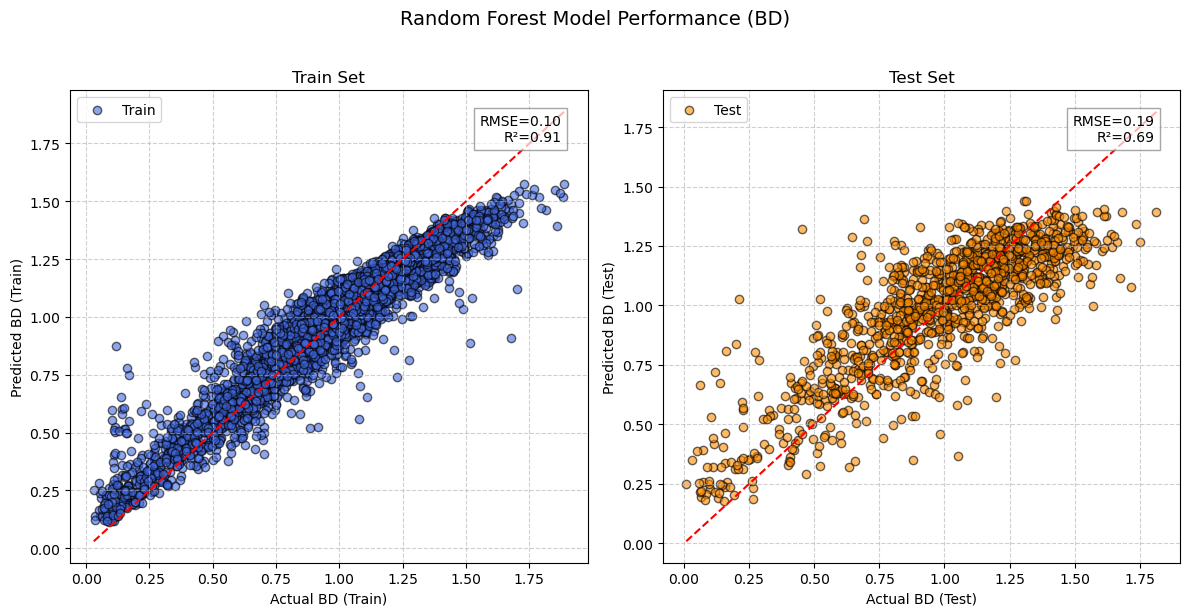

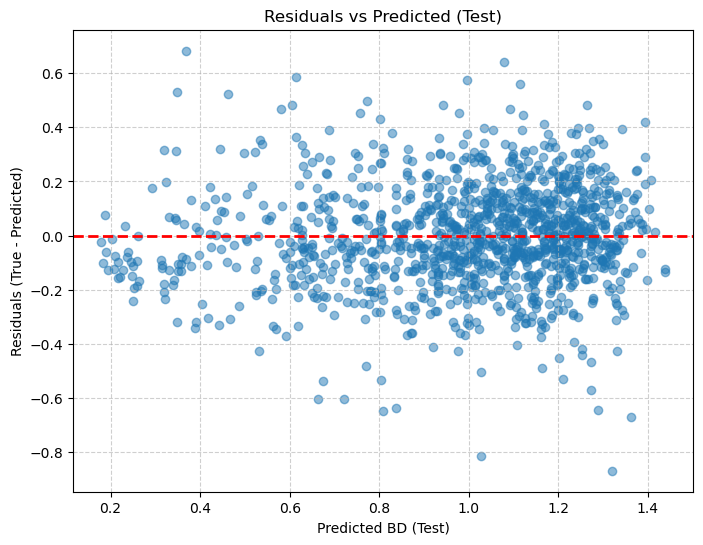

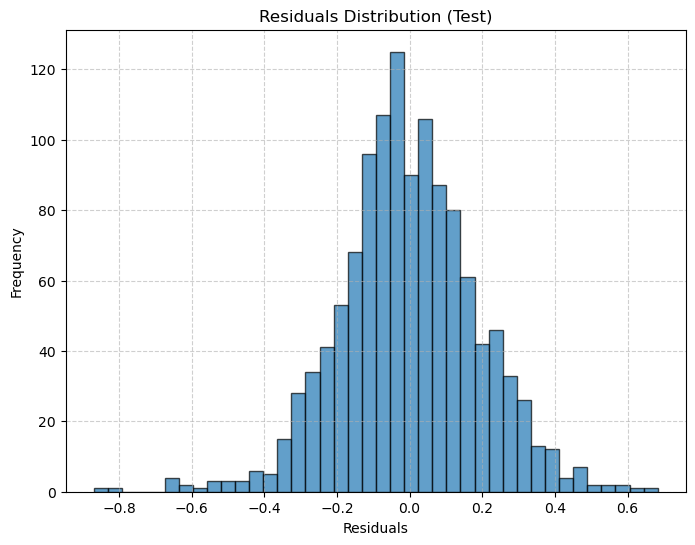

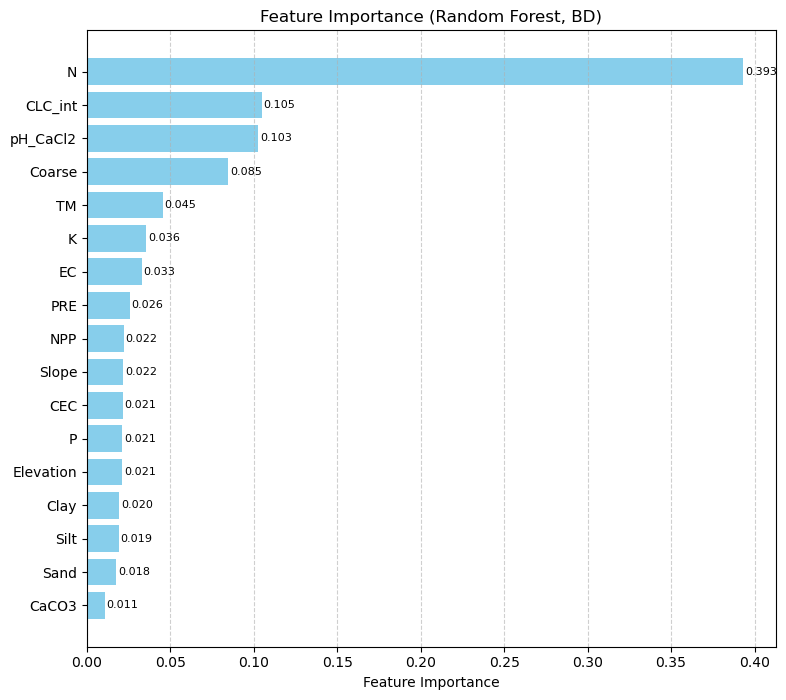

In [11]:
# ===============================
# Random Forest 绘图（单独脚本）
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_PATH = os.path.join(PREPROCESS_DIR, "model", "rf_BD.joblib")
TARGET = "BD"

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

# 保证和训练脚本一致的划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- 加载模型 ----------
try:
    final_model_rf = joblib.load(MODEL_PATH)
    print(f"✅ 已加载模型: {MODEL_PATH}")
except Exception as e:
    print(f"❌ 加载模型失败: {e}")
    raise SystemExit

# ---------- 预测 & 评估 ----------
y_pred_tr = final_model_rf.predict(X_train)
y_pred_te = final_model_rf.predict(X_test)

y_pred_tr[y_pred_tr < 0] = 0
y_pred_te[y_pred_te < 0] = 0

tr_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
tr_mae  = mean_absolute_error(y_train, y_pred_tr)
tr_r2   = r2_score(y_train, y_pred_tr)

te_rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
te_mae  = mean_absolute_error(y_test, y_pred_te)
te_r2   = r2_score(y_test, y_pred_te)

print("\n--- 评估指标 ---")
print(f"Train: RMSE={tr_rmse:.4f}, MAE={tr_mae:.4f}, R2={tr_r2:.4f}")
print(f"Test : RMSE={te_rmse:.4f}, MAE={te_mae:.4f}, R2={te_r2:.4f}")

# ===============================
# 图1: 实际 vs 预测（训练/测试 分开）
# ===============================
plt.figure(figsize=(12, 6))

# --- Train ---
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_tr, alpha=0.6, c="royalblue", edgecolor="k", label="Train")
minv = min(y_train.min(), y_pred_tr.min())
maxv = max(y_train.max(), y_pred_tr.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel(f"Actual {TARGET} (Train)")
plt.ylabel(f"Predicted {TARGET} (Train)")
plt.title("Train Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.text(
    0.95, 0.95,
    f"RMSE={tr_rmse:.2f}\nR²={tr_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10, ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

# --- Test ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_te, alpha=0.6, c="darkorange", edgecolor="k", label="Test")
minv = min(y_test.min(), y_pred_te.min())
maxv = max(y_test.max(), y_pred_te.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel(f"Actual {TARGET} (Test)")
plt.ylabel(f"Predicted {TARGET} (Test)")
plt.title("Test Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.text(
    0.95, 0.95,
    f"RMSE={te_rmse:.2f}\nR²={te_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10, ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.suptitle(f"Random Forest Model Performance ({TARGET})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# 图2: 残差 vs 预测（测试集）
# ===============================
resid_te = y_test - y_pred_te
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_te, resid_te, alpha=0.5)
plt.axhline(0, color="r", linestyle="--", lw=2)
plt.xlabel(f"Predicted {TARGET} (Test)")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ===============================
# 图3: 残差分布（测试集）
# ===============================
plt.figure(figsize=(8, 6))
plt.hist(resid_te, bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ===============================
# 图4: 特征重要性
# ===============================
importances = final_model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(8, len(feature_names) * 0.3 + 2))
plt.barh(range(len(importances)), importances[indices], align="center", color="skyblue")
plt.yticks(range(len(importances)), [feature_names[i] for i in indices], fontsize=10)
plt.xlabel("Feature Importance")
plt.title(f"Feature Importance (Random Forest, {TARGET})")
plt.gca().invert_yaxis()
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## CV

### 训练模型

In [8]:
# ===============================
# Random Forest + Optuna (训练+结果)
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")   # 注意 RF 用的是 tree 版
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")

MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "CV"  # 或 "CV"
MODEL_PATH = os.path.join(MODEL_DIR, f"rf_{TARGET}.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'rf_{TARGET}_study.db')}"

SEED = 42
TEST_SIZE = 0.2
CV_FOLDS = 10
OPTUNA_TIMEOUT = 1200

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# ---------- Optuna 目标函数 ----------
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1400, step=100),
        "max_depth": trial.suggest_int("max_depth", 10, 60, step=5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.6, 0.8, 1.0]),
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    scorer = make_scorer(mean_squared_error, greater_is_better=False)

    try:
        cv_scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring=scorer, n_jobs=-1)
        rmse = np.sqrt(-cv_scores.mean())
    except Exception as e:
        print(f"Trial {trial.number} 出错: {e}")
        return float("inf")
    return rmse

# ---------- Optuna 搜索 ----------
study_rf = optuna.create_study(
    study_name=f"rf_{TARGET}_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize"
)
print("\n--- 开始 Optuna 调参 (RF) ---")
study_rf.optimize(objective_rf, timeout=OPTUNA_TIMEOUT)
print("--- Optuna 完成 ---")
print("最佳参数: ", study_rf.best_params)

# ---------- 训练最终模型 ----------
final_model_rf = RandomForestRegressor(**study_rf.best_params, random_state=SEED, n_jobs=-1)
final_model_rf.fit(X_train, y_train)
joblib.dump(final_model_rf, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ---------- 查看结果 ----------
y_pred_tr = final_model_rf.predict(X_train)
y_pred_te = final_model_rf.predict(X_test)

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_tr)),
    "Train_MAE": mean_absolute_error(y_train, y_pred_tr),
    "Train_R2": r2_score(y_train, y_pred_tr),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_te),
    "Test_R2": r2_score(y_test, y_pred_te),
}
print("\n--- RF 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")




训练集: (4841, 17), 测试集: (1211, 17)


[I 2025-08-29 17:38:54,319] A new study created in RDB with name: rf_CV_hpo



--- 开始 Optuna 调参 (RF) ---


[I 2025-08-29 17:39:18,312] Trial 0 finished with value: 0.02041747873237851 and parameters: {'n_estimators': 1100, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.02041747873237851.
[I 2025-08-29 17:39:55,675] Trial 1 finished with value: 0.017149304269054876 and parameters: {'n_estimators': 700, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 0.8}. Best is trial 1 with value: 0.017149304269054876.
[I 2025-08-29 17:40:24,173] Trial 2 finished with value: 0.019745672729034054 and parameters: {'n_estimators': 1100, 'max_depth': 50, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.017149304269054876.
[I 2025-08-29 17:40:27,257] Trial 3 finished with value: 0.02058593753537097 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.01

--- Optuna 完成 ---
最佳参数:  {'n_estimators': 1000, 'max_depth': 40, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.8}
✅ 模型已保存: E:\Project-yqr\828update\BD\model\rf_CV.joblib

--- RF 模型评估 ---
Train_RMSE: 0.0085
Train_MAE: 0.0044
Train_R2: 0.9753
Test_RMSE: 0.0151
Test_MAE: 0.0089
Test_R2: 0.9257


### 绘图

✅ 已加载模型: E:\Project-yqr\828update\BD\model\rf_CV.joblib

--- 评估指标 ---
Train: RMSE=0.0085, MAE=0.0044, R2=0.9753
Test : RMSE=0.0151, MAE=0.0089, R2=0.9257


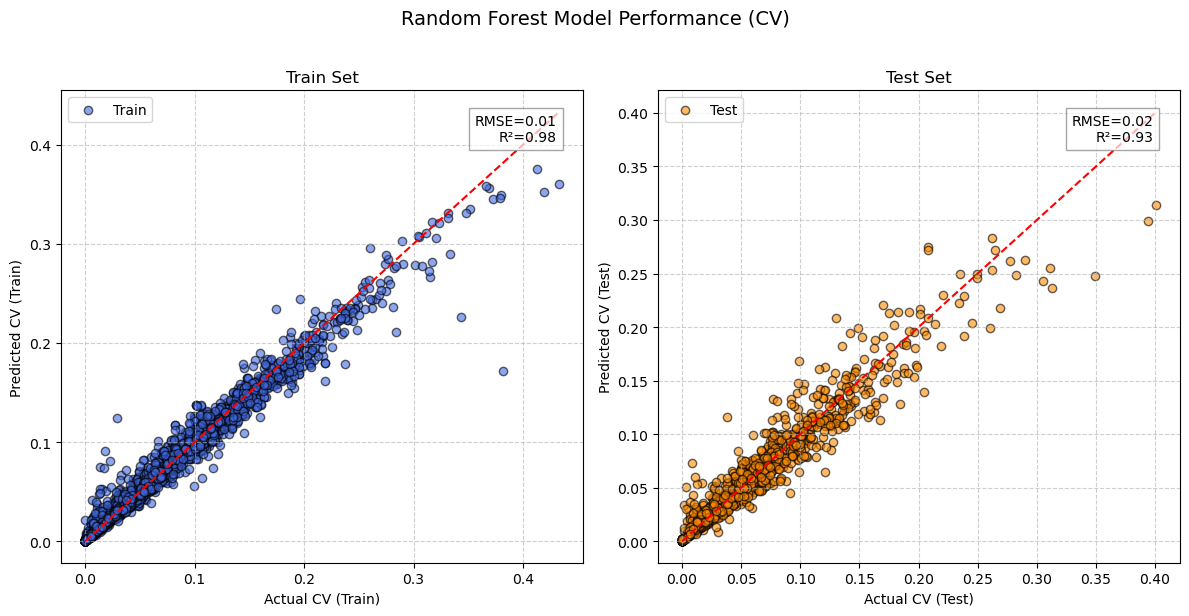

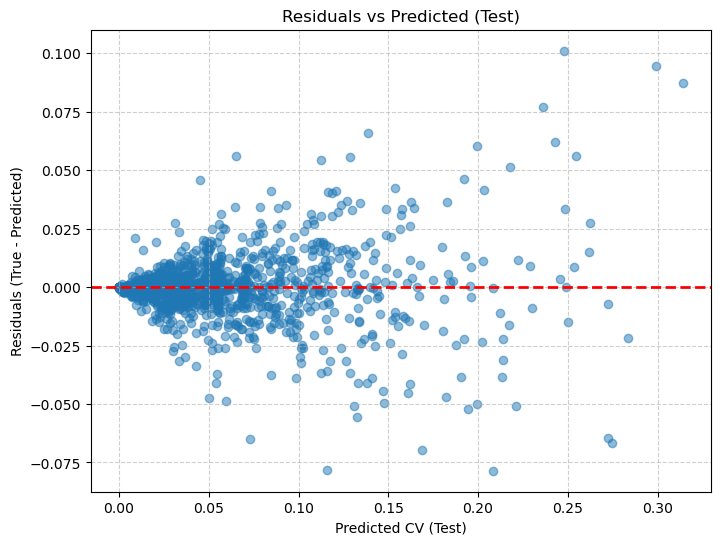

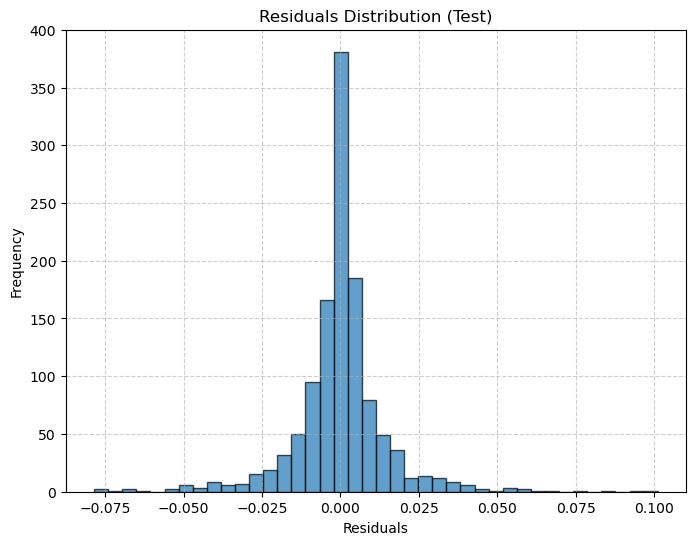

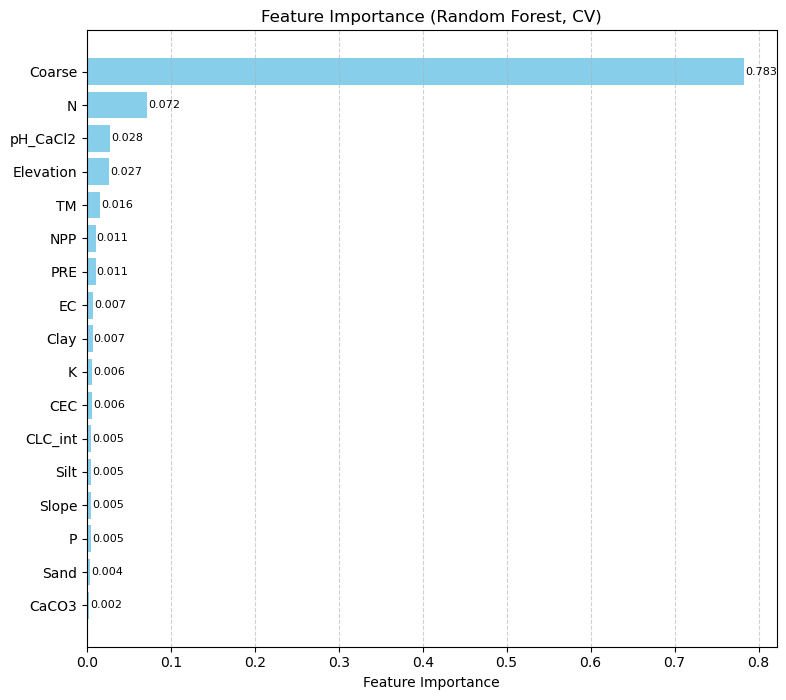

In [12]:
# ===============================
# Random Forest 绘图（单独脚本）
# ===============================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_PATH = os.path.join(PREPROCESS_DIR, "model", "rf_CV.joblib")
TARGET = "CV"

# ---------- 读取数据 ----------
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

# 保证和训练脚本一致的划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- 加载模型 ----------
try:
    final_model_rf = joblib.load(MODEL_PATH)
    print(f"✅ 已加载模型: {MODEL_PATH}")
except Exception as e:
    print(f"❌ 加载模型失败: {e}")
    raise SystemExit

# ---------- 预测 & 评估 ----------
y_pred_tr = final_model_rf.predict(X_train)
y_pred_te = final_model_rf.predict(X_test)

y_pred_tr[y_pred_tr < 0] = 0
y_pred_te[y_pred_te < 0] = 0

tr_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
tr_mae  = mean_absolute_error(y_train, y_pred_tr)
tr_r2   = r2_score(y_train, y_pred_tr)

te_rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
te_mae  = mean_absolute_error(y_test, y_pred_te)
te_r2   = r2_score(y_test, y_pred_te)

print("\n--- 评估指标 ---")
print(f"Train: RMSE={tr_rmse:.4f}, MAE={tr_mae:.4f}, R2={tr_r2:.4f}")
print(f"Test : RMSE={te_rmse:.4f}, MAE={te_mae:.4f}, R2={te_r2:.4f}")

# ===============================
# 图1: 实际 vs 预测（训练/测试 分开）
# ===============================
plt.figure(figsize=(12, 6))

# --- Train ---
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_tr, alpha=0.6, c="royalblue", edgecolor="k", label="Train")
minv = min(y_train.min(), y_pred_tr.min())
maxv = max(y_train.max(), y_pred_tr.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel(f"Actual {TARGET} (Train)")
plt.ylabel(f"Predicted {TARGET} (Train)")
plt.title("Train Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.text(
    0.95, 0.95,
    f"RMSE={tr_rmse:.2f}\nR²={tr_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10, ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

# --- Test ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_te, alpha=0.6, c="darkorange", edgecolor="k", label="Test")
minv = min(y_test.min(), y_pred_te.min())
maxv = max(y_test.max(), y_pred_te.max())
plt.plot([minv, maxv], [minv, maxv], "r--")
plt.xlabel(f"Actual {TARGET} (Test)")
plt.ylabel(f"Predicted {TARGET} (Test)")
plt.title("Test Set")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.text(
    0.95, 0.95,
    f"RMSE={te_rmse:.2f}\nR²={te_r2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10, ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)

plt.suptitle(f"Random Forest Model Performance ({TARGET})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# 图2: 残差 vs 预测（测试集）
# ===============================
resid_te = y_test - y_pred_te
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_te, resid_te, alpha=0.5)
plt.axhline(0, color="r", linestyle="--", lw=2)
plt.xlabel(f"Predicted {TARGET} (Test)")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ===============================
# 图3: 残差分布（测试集）
# ===============================
plt.figure(figsize=(8, 6))
plt.hist(resid_te, bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ===============================
# 图4: 特征重要性
# ===============================
importances = final_model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(8, len(feature_names) * 0.3 + 2))
plt.barh(range(len(importances)), importances[indices], align="center", color="skyblue")
plt.yticks(range(len(importances)), [feature_names[i] for i in indices], fontsize=10)
plt.xlabel("Feature Importance")
plt.title(f"Feature Importance (Random Forest, {TARGET})")
plt.gca().invert_yaxis()
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# GBM

## BD

### 训练模型

In [3]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import optuna

# ===============================
# 路径与参数配置
# ===============================
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "BD"
MODEL_PATH = os.path.join(MODEL_DIR, f"xgb_{TARGET}.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'xgb_{TARGET}_study.db')}"

SEED = 42
TEST_SIZE = 0.2
OPTUNA_TIMEOUT = 1200

# ===============================
# 数据加载与划分
# ===============================
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED
)

print(f"训练集: {X_train_full.shape}, 测试集: {X_test.shape}")
print(f"Optuna训练集: {X_optuna_train.shape}, 最终验证集: {X_final_val.shape}")

# ===============================
# Optuna 目标函数
# ===============================
def objective_xgb(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=50),
        'random_state': SEED,
        'n_jobs': -1
    }

    if param['booster'] == 'dart':
        param['sample_type'] = trial.suggest_categorical('sample_type', ['uniform', 'weighted'])
        param['normalize_type'] = trial.suggest_categorical('normalize_type', ['tree', 'forest'])
        param['rate_drop'] = trial.suggest_float('rate_drop', 0.0, 0.5)
        param['skip_drop'] = trial.suggest_float('skip_drop', 0.0, 0.5)

    model = xgb.XGBRegressor(**param)
    model.fit(X_optuna_train, y_optuna_train,
              eval_set=[(X_final_val, y_final_val)],
              verbose=False)
    y_pred_val = model.predict(X_final_val)
    y_pred_val[y_pred_val < 0] = 0
    rmse = np.sqrt(mean_squared_error(y_final_val, y_pred_val))
    return rmse

# ===============================
# Optuna 搜索
# ===============================
study = optuna.create_study(study_name=f"xgb_{TARGET}_hpo", storage=OPTUNA_DB, load_if_exists=True, direction="minimize")
study.optimize(objective_xgb, timeout=OPTUNA_TIMEOUT)
print("Optuna 最佳参数:", study.best_params)

# ===============================
# 最终模型训练
# ===============================
final_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'n_estimators': 2000
}
final_params.update({k: v for k, v in study.best_params.items() if k != 'n_estimators'})

final_model_xgb = xgb.XGBRegressor(**final_params)
final_model_xgb.fit(X_optuna_train, y_optuna_train, eval_set=[(X_final_val, y_final_val)], verbose=False)
print(f"最佳迭代次数: {final_model_xgb.best_iteration + 1}")

joblib.dump(final_model_xgb, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ===============================
# 评估
# ===============================
y_pred_train = final_model_xgb.predict(X_optuna_train)
y_pred_test = final_model_xgb.predict(X_test)
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_optuna_train, y_pred_train)),
    "Train_MAE": mean_absolute_error(y_optuna_train, y_pred_train),
    "Train_R2": r2_score(y_optuna_train, y_pred_train),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_test),
    "Test_R2": r2_score(y_test, y_pred_test),
}
print("\n--- 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


[I 2025-08-29 16:04:40,310] Using an existing study with name 'xgb_BD_hpo' instead of creating a new one.


训练集: (4841, 17), 测试集: (1211, 17)
Optuna训练集: (4114, 17), 最终验证集: (727, 17)


[I 2025-08-29 16:04:42,314] Trial 2 finished with value: 0.1959757601407776 and parameters: {'booster': 'gbtree', 'learning_rate': 0.016215757378661013, 'max_depth': 5, 'min_child_weight': 2, 'gamma': 0.2370795400729887, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_alpha': 0.5581027662939229, 'reg_lambda': 0.44490817161770935, 'n_estimators': 600}. Best is trial 2 with value: 0.1959757601407776.
[I 2025-08-29 16:06:46,208] Trial 3 finished with value: 0.1998372868735362 and parameters: {'booster': 'dart', 'learning_rate': 0.02063009167627799, 'max_depth': 8, 'min_child_weight': 2, 'gamma': 0.3887046604326732, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_alpha': 0.38520162580341677, 'reg_lambda': 0.15056648349833857, 'n_estimators': 700, 'sample_type': 'weighted', 'normalize_type': 'forest', 'rate_drop': 0.16236633822451035, 'skip_drop': 0.24681836630107007}. Best is trial 2 with value: 0.1959757601407776.
[I 2025-08-29 16:06:48,534] Trial 4 finished with value: 0.1986822787626887

Optuna 最佳参数: {'booster': 'dart', 'learning_rate': 0.028071914621679322, 'max_depth': 11, 'min_child_weight': 1, 'gamma': 0.05689961317050635, 'subsample': 0.7, 'colsample_bytree': 0.8, 'reg_alpha': 0.4159213742631004, 'reg_lambda': 0.5581996855928998, 'n_estimators': 700, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 0.38016505495282227, 'skip_drop': 0.4204513638321939}
最佳迭代次数: 744
✅ 模型已保存: E:\Project-yqr\828update\BD\model\xgb_BD.joblib

--- 模型评估 ---
Train_RMSE: 0.1172
Train_MAE: 0.0908
Train_R2: 0.8838
Test_RMSE: 0.1875
Test_MAE: 0.1445
Test_R2: 0.7001


In [5]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import optuna

# ===============================
# 路径与参数配置
# ===============================
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "BD"
MODEL_PATH = os.path.join(MODEL_DIR, f"xgb_{TARGET}_cv.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'xgb_{TARGET}_cv_study.db')}"

SEED = 42
TEST_SIZE = 0.2
OPTUNA_TIMEOUT = 2400
N_TRIALS = 100

# ===============================
# 数据加载与划分
# ===============================
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED
)

print(f"训练集: {X_train_full.shape}, 测试集: {X_test.shape}")
print(f"Optuna训练集: {X_optuna_train.shape}, 最终验证集: {X_final_val.shape}")

# ===============================
# Optuna 目标函数 (KFold CV)
# ===============================
def objective_xgb(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': trial.suggest_categorical('booster', ['gbtree']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': SEED,
        'n_jobs': -1,
        'early_stopping_rounds': 50
    }

    model = xgb.XGBRegressor(**param)

    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []

    for train_idx, val_idx in kf.split(X_optuna_train, y_optuna_train):
        X_train_fold, X_val_fold = X_optuna_train.iloc[train_idx], X_optuna_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_optuna_train.iloc[train_idx], y_optuna_train.iloc[val_idx]

        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False
        )
        y_pred = model.predict(X_val_fold, iteration_range=(0, model.best_iteration))
        y_pred[y_pred < 0] = 0
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
        rmses.append(rmse)

    return np.mean(rmses)

# ===============================
# Optuna 搜索
# ===============================
study = optuna.create_study(
    study_name=f"xgb_{TARGET}_cv_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize"
)
study.optimize(objective_xgb, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)
print("Optuna 最佳参数:", study.best_params)

# ===============================
# 最终模型训练 (独立验证集 + 早停)
# ===============================
final_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'n_estimators': 2000
}
final_params.update({k: v for k, v in study.best_params.items() if k != 'n_estimators'})

final_model_xgb = xgb.XGBRegressor(**final_params)
final_model_xgb.fit(
    X_optuna_train, y_optuna_train,
    eval_set=[(X_final_val, y_final_val)],
    verbose=False
)
print(f"最佳迭代次数: {final_model_xgb.best_iteration + 1}")

joblib.dump(final_model_xgb, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ===============================
# 评估
# ===============================
y_pred_train = final_model_xgb.predict(X_optuna_train, iteration_range=(0, final_model_xgb.best_iteration))
y_pred_test = final_model_xgb.predict(X_test, iteration_range=(0, final_model_xgb.best_iteration))
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_optuna_train, y_pred_train)),
    "Train_MAE": mean_absolute_error(y_optuna_train, y_pred_train),
    "Train_R2": r2_score(y_optuna_train, y_pred_train),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_test),
    "Test_R2": r2_score(y_test, y_pred_test),
}
print("\n--- 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


训练集: (4841, 17), 测试集: (1211, 17)
Optuna训练集: (4114, 17), 最终验证集: (727, 17)


[I 2025-09-04 22:39:52,032] A new study created in RDB with name: xgb_BD_cv_hpo
[I 2025-09-04 22:39:55,756] Trial 0 finished with value: 0.19701195918668168 and parameters: {'booster': 'gbtree', 'n_estimators': 1300, 'learning_rate': 0.018188187162812248, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0.2514984987432258, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0.3355626588028222, 'reg_lambda': 0.45070268370939004}. Best is trial 0 with value: 0.19701195918668168.
[I 2025-09-04 22:40:01,515] Trial 1 finished with value: 0.1946795285907646 and parameters: {'booster': 'gbtree', 'n_estimators': 1450, 'learning_rate': 0.013026077120846552, 'max_depth': 11, 'min_child_weight': 3, 'gamma': 0.1629092487055404, 'subsample': 0.8, 'colsample_bytree': 0.6, 'reg_alpha': 0.053709885156659865, 'reg_lambda': 0.46388612849566535}. Best is trial 1 with value: 0.1946795285907646.
[I 2025-09-04 22:40:04,338] Trial 2 finished with value: 0.19735680669678224 and parameters: {'booster': 'gbt

Optuna 最佳参数: {'booster': 'gbtree', 'n_estimators': 950, 'learning_rate': 0.011864780130937336, 'max_depth': 7, 'min_child_weight': 6, 'gamma': 0.023278007561798444, 'subsample': 0.6, 'colsample_bytree': 0.9, 'reg_alpha': 0.19918131042667495, 'reg_lambda': 0.9465213250800275}
最佳迭代次数: 601
✅ 模型已保存: E:\Project-yqr\828update\BD\model\xgb_BD_cv.joblib

--- 模型评估 ---
Train_RMSE: 0.1178
Train_MAE: 0.0903
Train_R2: 0.8826
Test_RMSE: 0.1849
Test_MAE: 0.1422
Test_R2: 0.7083


### 绘图

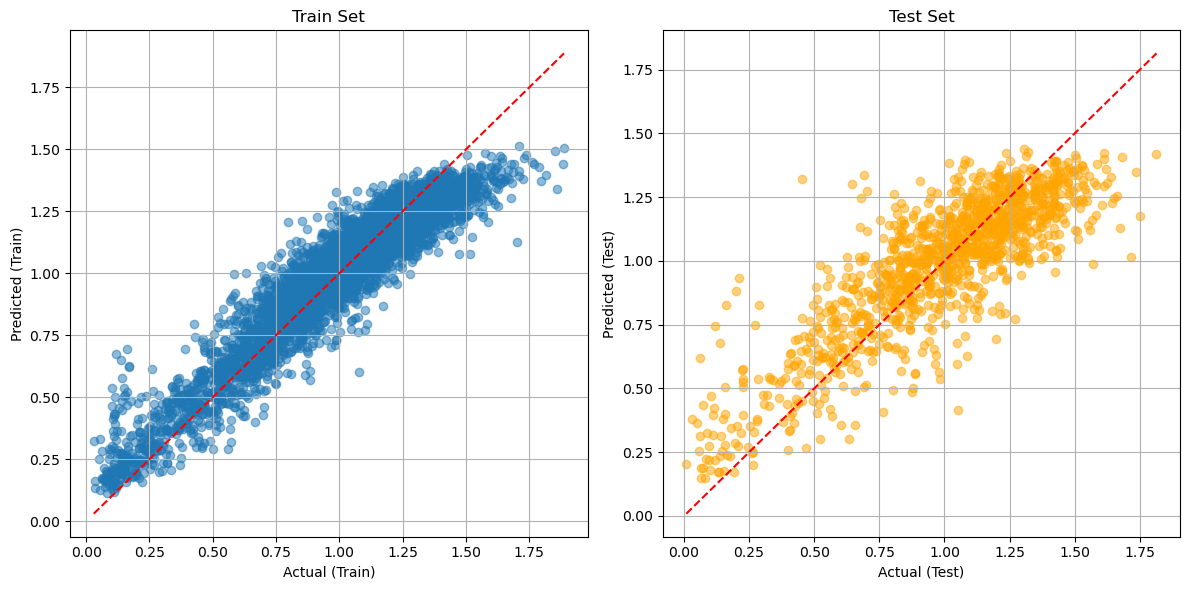

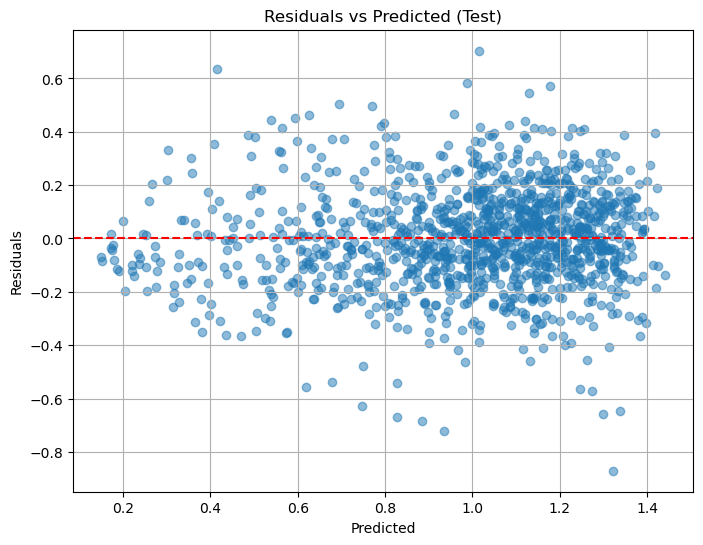

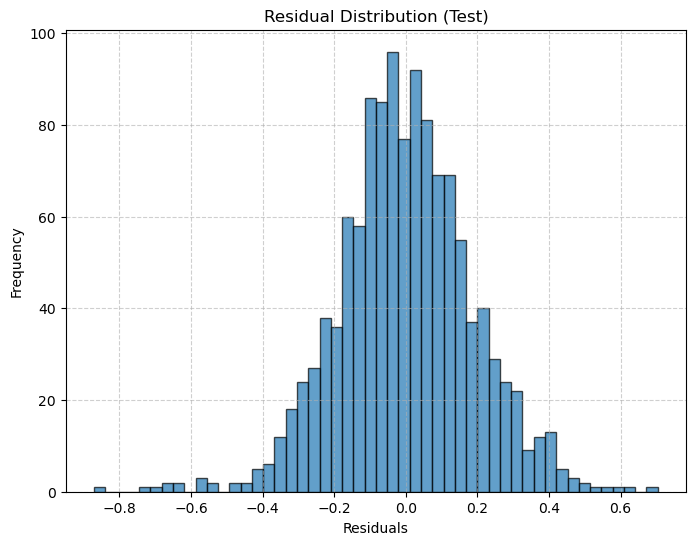

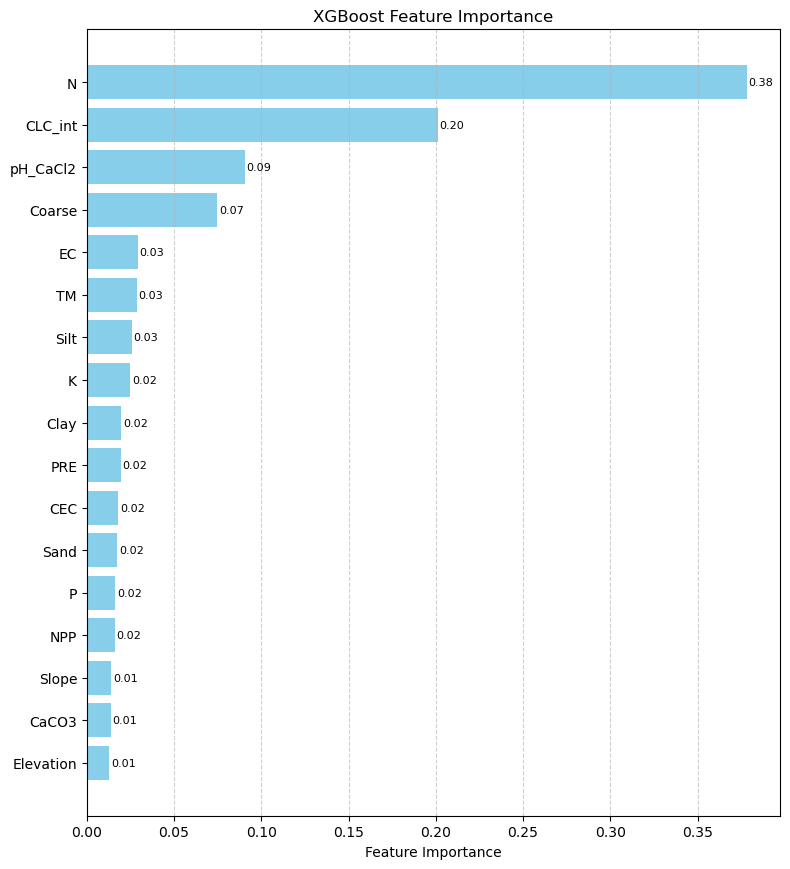

In [10]:
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 加载模型与数据
# ===============================
MODEL_PATH = r"E:\Project-yqr\828update\BD\model\xgb_BD.joblib"
final_model_xgb = joblib.load(MODEL_PATH)

# 数据
X_train = pd.read_csv(r"E:\Project-yqr\828update\BD\X_for_tree.csv")
y = pd.read_csv(r"E:\Project-yqr\828update\BD\targets.csv")["BD"]
X_train_full, X_test, y_train_full, y_test = train_test_split(X_train, y, test_size=0.2, random_state=42)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

y_pred_train = final_model_xgb.predict(X_optuna_train)
y_pred_test = final_model_xgb.predict(X_test)
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

# ===============================
# 预测 vs 实际散点图
# ===============================
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(y_optuna_train, y_pred_train, alpha=0.5)
plt.plot([y_optuna_train.min(), y_optuna_train.max()], [y_optuna_train.min(), y_optuna_train.max()], 'r--')
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("Train Set")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual (Test)")
plt.ylabel("Predicted (Test)")
plt.title("Test Set")
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# 残差图 & 直方图
# ===============================
residuals = y_test - y_pred_test

plt.figure(figsize=(8,6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ===============================
# 特征重要性
# ===============================
feature_names = X_train.columns
importances = final_model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, len(feature_names)*0.4+2))
plt.barh(range(len(importances)), importances[indices], color='skyblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v:.2f}", va='center', fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## CV

### 训练模型

In [18]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import optuna

# ===============================
# 路径与参数配置
# ===============================
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "CV"
MODEL_PATH = os.path.join(MODEL_DIR, f"xgb_{TARGET}.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'xgb_{TARGET}_study.db')}"

SEED = 42
TEST_SIZE = 0.2
OPTUNA_TIMEOUT = 2400

# ===============================
# 数据加载与划分
# ===============================
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED
)

print(f"训练集: {X_train_full.shape}, 测试集: {X_test.shape}")
print(f"Optuna训练集: {X_optuna_train.shape}, 最终验证集: {X_final_val.shape}")

# ===============================
# Optuna 目标函数
# ===============================
def objective_xgb(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=50),
        'random_state': SEED,
        'n_jobs': -1
    }

    if param['booster'] == 'dart':
        param['sample_type'] = trial.suggest_categorical('sample_type', ['uniform', 'weighted'])
        param['normalize_type'] = trial.suggest_categorical('normalize_type', ['tree', 'forest'])
        param['rate_drop'] = trial.suggest_float('rate_drop', 0.0, 0.5)
        param['skip_drop'] = trial.suggest_float('skip_drop', 0.0, 0.5)

    model = xgb.XGBRegressor(**param)
    model.fit(X_optuna_train, y_optuna_train,
              eval_set=[(X_final_val, y_final_val)],
              verbose=False)
    y_pred_val = model.predict(X_final_val)
    y_pred_val[y_pred_val < 0] = 0
    rmse = np.sqrt(mean_squared_error(y_final_val, y_pred_val))
    return rmse

# ===============================
# Optuna 搜索
# ===============================
study = optuna.create_study(study_name=f"xgb_{TARGET}_hpo", storage=OPTUNA_DB, load_if_exists=True, direction="minimize")
study.optimize(objective_xgb, timeout=OPTUNA_TIMEOUT)
print("Optuna 最佳参数:", study.best_params)

# ===============================
# 最终模型训练
# ===============================
final_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'n_estimators': 2000
}
final_params.update({k: v for k, v in study.best_params.items() if k != 'n_estimators'})

final_model_xgb = xgb.XGBRegressor(**final_params)
final_model_xgb.fit(X_optuna_train, y_optuna_train, eval_set=[(X_final_val, y_final_val)], verbose=False)
print(f"最佳迭代次数: {final_model_xgb.best_iteration + 1}")

joblib.dump(final_model_xgb, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ===============================
# 评估
# ===============================
y_pred_train = final_model_xgb.predict(X_optuna_train)
y_pred_test = final_model_xgb.predict(X_test)
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_optuna_train, y_pred_train)),
    "Train_MAE": mean_absolute_error(y_optuna_train, y_pred_train),
    "Train_R2": r2_score(y_optuna_train, y_pred_train),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_test),
    "Test_R2": r2_score(y_test, y_pred_test),
}
print("\n--- 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


训练集: (4841, 17), 测试集: (1211, 17)
Optuna训练集: (4114, 17), 最终验证集: (727, 17)


[I 2025-09-01 23:23:13,711] Using an existing study with name 'xgb_CV_hpo' instead of creating a new one.
[I 2025-09-01 23:43:17,104] Trial 15 finished with value: 0.02587598177898493 and parameters: {'booster': 'dart', 'learning_rate': 0.07858857768603014, 'max_depth': 7, 'min_child_weight': 10, 'gamma': 0.164532794685924, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.886414945069488, 'reg_lambda': 0.13617117572637874, 'n_estimators': 2000, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.36366504382890075, 'skip_drop': 0.30417697971043134}. Best is trial 12 with value: 0.022364649846341296.
[I 2025-09-01 23:59:51,160] Trial 16 finished with value: 0.02382974518636318 and parameters: {'booster': 'dart', 'learning_rate': 0.007666144011465528, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.06448669402229967, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.9981356872793921, 'reg_lambda': 0.15783260957178802, 'n_estimators': 1750, 'sample_type'

Optuna 最佳参数: {'booster': 'dart', 'learning_rate': 0.005982128659435533, 'max_depth': 6, 'min_child_weight': 8, 'gamma': 0.00013780155572693398, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.7670938279277841, 'reg_lambda': 0.009075212135006526, 'n_estimators': 1650, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.3172751070524653, 'skip_drop': 0.2241216737508379}
最佳迭代次数: 670
✅ 模型已保存: E:\Project-yqr\828update\BD\model\xgb_CV.joblib

--- 模型评估 ---
Train_RMSE: 0.0209
Train_MAE: 0.0139
Train_R2: 0.8497
Test_RMSE: 0.0224
Test_MAE: 0.0150
Test_R2: 0.8356


In [4]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import optuna

# ===============================
# 路径与参数配置
# ===============================
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
X_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
Y_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")
MODEL_DIR = os.path.join(PREPROCESS_DIR, "model")
DB_DIR = os.path.join(PREPROCESS_DIR, "database")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

TARGET = "CV"
MODEL_PATH = os.path.join(MODEL_DIR, f"xgb_{TARGET}_cv.joblib")
OPTUNA_DB = f"sqlite:///{os.path.join(DB_DIR, f'xgb_{TARGET}_cv_study.db')}"

SEED = 42
TEST_SIZE = 0.2
OPTUNA_TIMEOUT = 2400
N_TRIALS = 100

# ===============================
# 数据加载与划分
# ===============================
X = pd.read_csv(X_PATH)
y = pd.read_csv(Y_PATH)[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED
)

print(f"训练集: {X_train_full.shape}, 测试集: {X_test.shape}")
print(f"Optuna训练集: {X_optuna_train.shape}, 最终验证集: {X_final_val.shape}")

# ===============================
# Optuna 目标函数 (KFold CV)
# ===============================
def objective_xgb(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': trial.suggest_categorical('booster', ['gbtree']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': SEED,
        'n_jobs': -1,
        'early_stopping_rounds': 50
    }

    model = xgb.XGBRegressor(**param)

    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []

    for train_idx, val_idx in kf.split(X_optuna_train, y_optuna_train):
        X_train_fold, X_val_fold = X_optuna_train.iloc[train_idx], X_optuna_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_optuna_train.iloc[train_idx], y_optuna_train.iloc[val_idx]

        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False
        )
        y_pred = model.predict(X_val_fold, iteration_range=(0, model.best_iteration))
        y_pred[y_pred < 0] = 0
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
        rmses.append(rmse)

    return np.mean(rmses)

# ===============================
# Optuna 搜索
# ===============================
study = optuna.create_study(
    study_name=f"xgb_{TARGET}_cv_hpo",
    storage=OPTUNA_DB,
    load_if_exists=True,
    direction="minimize"
)
study.optimize(objective_xgb, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)
print("Optuna 最佳参数:", study.best_params)

# ===============================
# 最终模型训练 (独立验证集 + 早停)
# ===============================
final_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'n_estimators': 2000
}
final_params.update({k: v for k, v in study.best_params.items() if k != 'n_estimators'})

final_model_xgb = xgb.XGBRegressor(**final_params)
final_model_xgb.fit(
    X_optuna_train, y_optuna_train,
    eval_set=[(X_final_val, y_final_val)],
    verbose=False
)
print(f"最佳迭代次数: {final_model_xgb.best_iteration + 1}")

joblib.dump(final_model_xgb, MODEL_PATH)
print(f"✅ 模型已保存: {MODEL_PATH}")

# ===============================
# 评估
# ===============================
y_pred_train = final_model_xgb.predict(X_optuna_train, iteration_range=(0, final_model_xgb.best_iteration))
y_pred_test = final_model_xgb.predict(X_test, iteration_range=(0, final_model_xgb.best_iteration))
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

metrics = {
    "Train_RMSE": np.sqrt(mean_squared_error(y_optuna_train, y_pred_train)),
    "Train_MAE": mean_absolute_error(y_optuna_train, y_pred_train),
    "Train_R2": r2_score(y_optuna_train, y_pred_train),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Test_MAE": mean_absolute_error(y_test, y_pred_test),
    "Test_R2": r2_score(y_test, y_pred_test),
}
print("\n--- 模型评估 ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


训练集: (4841, 17), 测试集: (1211, 17)
Optuna训练集: (4114, 17), 最终验证集: (727, 17)


[I 2025-09-04 22:35:01,275] A new study created in RDB with name: xgb_CV_cv_hpo
[I 2025-09-04 22:35:02,801] Trial 0 finished with value: 0.03161250663174388 and parameters: {'booster': 'gbtree', 'n_estimators': 150, 'learning_rate': 0.0316315741787896, 'max_depth': 8, 'min_child_weight': 8, 'gamma': 0.42600184264300656, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.8112412024442168, 'reg_lambda': 0.348443940861928}. Best is trial 0 with value: 0.03161250663174388.
[I 2025-09-04 22:35:05,798] Trial 1 finished with value: 0.028757353616051758 and parameters: {'booster': 'gbtree', 'n_estimators': 1150, 'learning_rate': 0.006823515644019573, 'max_depth': 5, 'min_child_weight': 8, 'gamma': 0.24395114113857624, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 0.5991704141906697, 'reg_lambda': 0.08835075045273544}. Best is trial 1 with value: 0.028757353616051758.
[I 2025-09-04 22:35:07,522] Trial 2 finished with value: 0.0231152706911367 and parameters: {'booster': 'gbtree

Optuna 最佳参数: {'booster': 'gbtree', 'n_estimators': 900, 'learning_rate': 0.018837766974443483, 'max_depth': 8, 'min_child_weight': 5, 'gamma': 0.000460489605088584, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2330378257959611, 'reg_lambda': 0.7997782282167807}
最佳迭代次数: 1213
✅ 模型已保存: E:\Project-yqr\828update\BD\model\xgb_CV_cv.joblib

--- 模型评估 ---
Train_RMSE: 0.0111
Train_MAE: 0.0073
Train_R2: 0.9577
Test_RMSE: 0.0155
Test_MAE: 0.0094
Test_R2: 0.9213


### 绘图

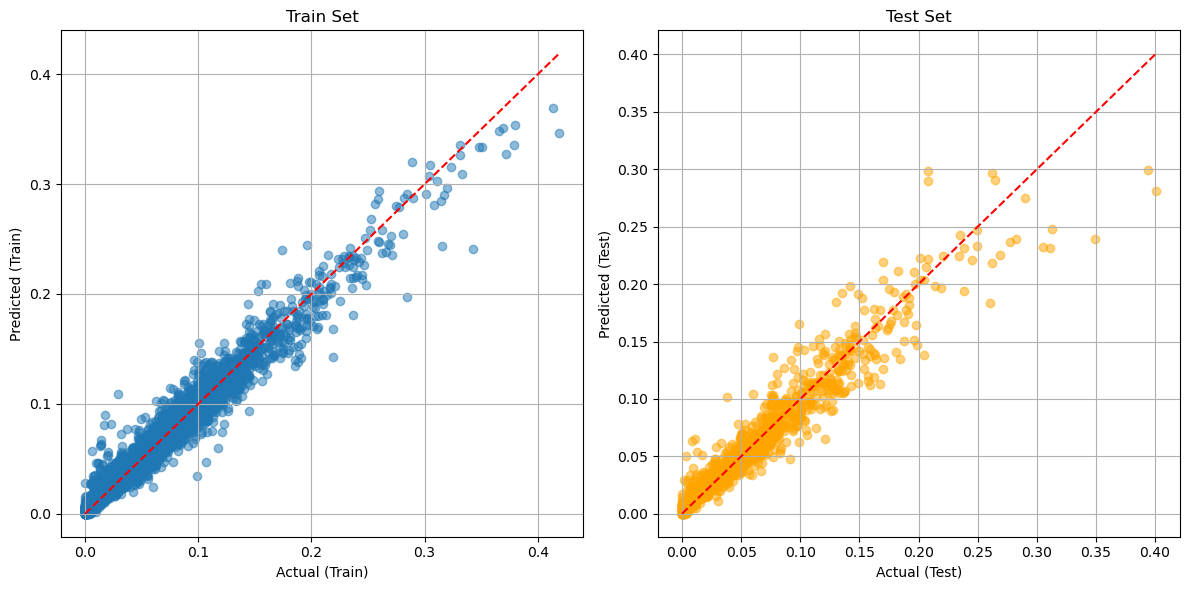

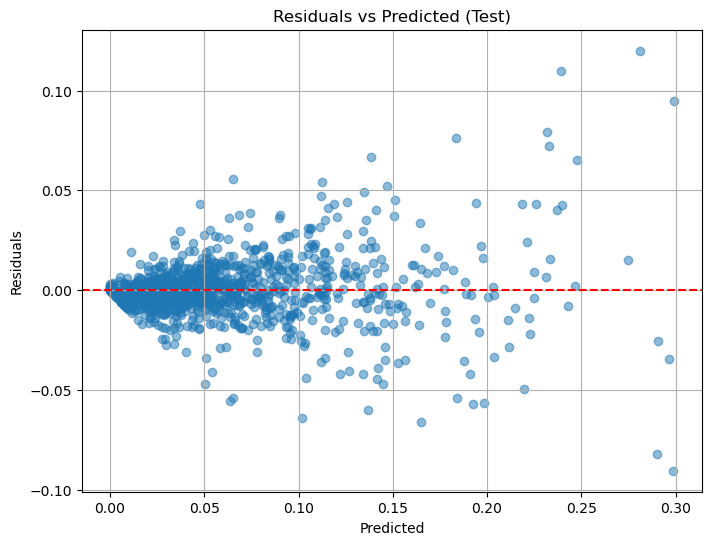

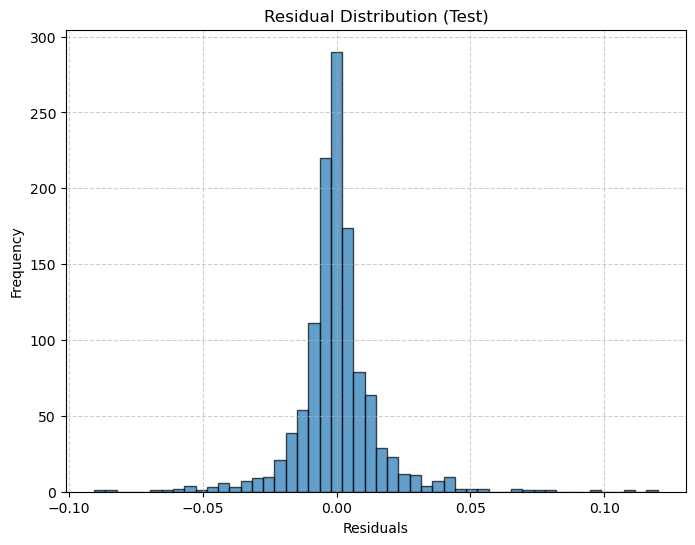

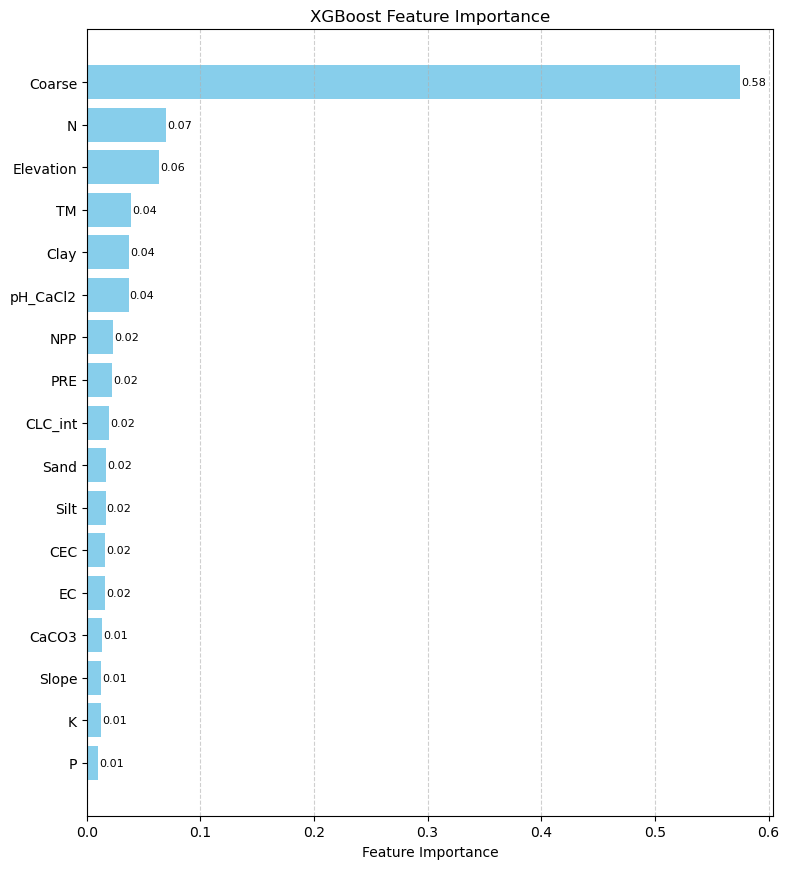

In [7]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
# ===============================
# 加载模型与数据
# ===============================
MODEL_PATH = r"E:\Project-yqr\828update\BD\model\xgb_CV_cv.joblib"
final_model_xgb = joblib.load(MODEL_PATH)

# 数据
X_train = pd.read_csv(r"E:\Project-yqr\828update\BD\X_for_tree.csv")
y = pd.read_csv(r"E:\Project-yqr\828update\BD\targets.csv")["CV"]
X_train_full, X_test, y_train_full, y_test = train_test_split(X_train, y, test_size=0.2, random_state=42)
X_optuna_train, X_final_val, y_optuna_train, y_final_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

y_pred_train = final_model_xgb.predict(X_optuna_train)
y_pred_test = final_model_xgb.predict(X_test)
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test < 0] = 0

# ===============================
# 预测 vs 实际散点图
# ===============================
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(y_optuna_train, y_pred_train, alpha=0.5)
plt.plot([y_optuna_train.min(), y_optuna_train.max()], [y_optuna_train.min(), y_optuna_train.max()], 'r--')
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("Train Set")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual (Test)")
plt.ylabel("Predicted (Test)")
plt.title("Test Set")
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# 残差图 & 直方图
# ===============================
residuals = y_test - y_pred_test

plt.figure(figsize=(8,6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ===============================
# 特征重要性
# ===============================
feature_names = X_train.columns
importances = final_model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, len(feature_names)*0.4+2))
plt.barh(range(len(importances)), importances[indices], color='skyblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v:.2f}", va='center', fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 填补

In [9]:
#%% 1. 环境 & 路径设置
import os
import pandas as pd
import numpy as np
import joblib

# ---------- 路径配置 ----------
PREPROCESS_DIR = r"E:\Project-yqr\828update\BD"
MODEL_DIR = r"E:\Project-yqr\828update\BD\model"
OUTPUT_DIR = r"E:\Project-yqr\828update\results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 预处理产物
X_TREE_PATH = os.path.join(PREPROCESS_DIR, "X_for_tree.csv")
X_CUBIST_PATH = os.path.join(PREPROCESS_DIR, "X_for_cubist.csv")
TARGET_PATH = os.path.join(PREPROCESS_DIR, "targets.csv")

# SOC 原始数据路径
SOC_PATHS = {
    "2018": r"E:\Project-yqr\new\data\SOC_2018_filled.csv",
    "2015": r"E:\Project-yqr\new\data\SOC_2015_filled.csv",
    "2009": r"E:\Project-yqr\new\data\SOC_2009_filled.csv",
}

# 模型列表
MODEL_TYPES = ["cubist", "rf", "xgb"]
#%% 2. 加载预处理数据
print("加载预处理数据...")
X_tree = pd.read_csv(X_TREE_PATH)
X_cubist = pd.read_csv(X_CUBIST_PATH)
targets = pd.read_csv(TARGET_PATH)
y_BD = targets["BD"].copy()
y_CV = targets["CV"].copy()

print(f"X_tree: {X_tree.shape}, X_cubist: {X_cubist.shape}, targets: {targets.shape}")

#%% 3. 循环所有模型，填补 BD/CV 并计算 SOC
for model_name in MODEL_TYPES:
    print(f"\n--- 处理模型: {model_name} ---")

    # 加载模型
    bd_model_path = os.path.join(MODEL_DIR, f"{model_name}_bd.joblib")
    cv_model_path = os.path.join(MODEL_DIR, f"{model_name}_cv.joblib")
    model_bd = joblib.load(bd_model_path)
    model_cv = joblib.load(cv_model_path)

    # 创建填补副本
    df_fill_tree = X_tree.copy()
    df_fill_cubist = X_cubist.copy()

    # -------- BD 填补 --------
    bd_missing_idx = y_BD[y_BD.isna()].index
    if len(bd_missing_idx) > 0:
        if model_name == "cubist":
            pred_bd = model_bd.predict(df_fill_cubist.loc[bd_missing_idx])
        else:
            pred_bd = model_bd.predict(df_fill_tree.loc[bd_missing_idx])
        pred_bd = np.clip(pred_bd, 0, None)
        y_BD.loc[bd_missing_idx] = pred_bd
        print(f"已填补 {len(bd_missing_idx)} 个 BD (最小值修正 0)")

    # -------- CV 填补 --------
    cv_missing_idx = y_CV[y_CV.isna()].index
    if len(cv_missing_idx) > 0:
        if model_name == "cubist":
            pred_cv = model_cv.predict(df_fill_cubist.loc[cv_missing_idx])
        else:
            pred_cv = model_cv.predict(df_fill_tree.loc[cv_missing_idx])
        pred_cv = np.clip(pred_cv, 0.001, None)
        y_CV.loc[cv_missing_idx] = pred_cv
        print(f"已填补 {len(cv_missing_idx)} 个 CV (最小值修正 0.001)")

    # -------- 合并填补结果 --------
    df_filled_all = X_tree.copy()
    df_filled_all["BD"] = y_BD
    df_filled_all["CV"] = y_CV

    # -------- SOC 计算函数 --------
    def compute_soc(df_oc, df_bd_cv, depth=0.2):
        df_merge = pd.merge(df_oc, df_bd_cv[["ID", "BD", "CV"]], on="ID", how="left")
        df_merge["CV"] = df_merge["CV"].clip(lower=0.001)
        df_merge["BD"] = df_merge["BD"].clip(lower=0)
        df_merge["SOC"] = depth * df_merge["BD"] * df_merge["OC"] * (1 - df_merge["CV"])
        df_merge["SOC"] = df_merge["SOC"].clip(lower=0)
        return df_merge

    # -------- 循环年份，计算 SOC --------
    for year, path in SOC_PATHS.items():
        try:
            df_oc = pd.read_csv(path)
            df_soc = compute_soc(df_oc, df_filled_all)
            output_file = os.path.join(OUTPUT_DIR, f"soc_filled_{year}_{model_name}.csv")
            df_soc.to_csv(output_file, index=False)
            print(f"✅ {year} 年 SOC 已保存: {output_file}")
        except FileNotFoundError:
            print(f"⚠️ {year} 年 SOC 文件未找到: {path}, 跳过。")
        except Exception as e:
            print(f"❌ {year} 年 SOC 计算出错: {e}")

#%% 4. 所有模型 SOC 平均
for year in SOC_PATHS.keys():
    dfs = []
    for model_name in MODEL_TYPES:
        file_path = os.path.join(OUTPUT_DIR, f"soc_filled_{year}_{model_name}.csv")
        try:
            df = pd.read_csv(file_path)[["ID", "SOC"]].set_index("ID")
            dfs.append(df)
        except Exception as e:
            print(f"⚠️ 加载 {model_name} {year} 年 SOC 出错: {e}")
    if dfs:
        df_avg = pd.concat(dfs, axis=1).mean(axis=1)
        df_avg = df_avg.clip(lower=0)
        original_oc_path = SOC_PATHS[year]
        try:
            df_oc = pd.read_csv(original_oc_path)
            df_final = pd.merge(df_oc, df_avg.reset_index().rename(columns={0:"SOC"}), on="ID", how="left")
        except:
            df_final = df_avg.reset_index().rename(columns={0:"SOC"})
        output_avg = os.path.join(OUTPUT_DIR, f"soc_filled_{year}_average.csv")
        df_final.to_csv(output_avg, index=False)
        print(f"✅ {year} 年平均 SOC 已保存: {output_avg}")


加载预处理数据...
X_tree: (6052, 17), X_cubist: (6052, 48), targets: (6052, 3)

--- 处理模型: cubist ---
❌ 2018 年 SOC 计算出错: "['ID'] not in index"
❌ 2015 年 SOC 计算出错: "['ID'] not in index"
❌ 2009 年 SOC 计算出错: "['ID'] not in index"

--- 处理模型: rf ---
❌ 2018 年 SOC 计算出错: "['ID'] not in index"
❌ 2015 年 SOC 计算出错: "['ID'] not in index"
❌ 2009 年 SOC 计算出错: "['ID'] not in index"

--- 处理模型: xgb ---
❌ 2018 年 SOC 计算出错: "['ID'] not in index"
❌ 2015 年 SOC 计算出错: "['ID'] not in index"
❌ 2009 年 SOC 计算出错: "['ID'] not in index"
⚠️ 加载 cubist 2018 年 SOC 出错: [Errno 2] No such file or directory: 'E:\\Project-yqr\\828update\\results\\soc_filled_2018_cubist.csv'
⚠️ 加载 rf 2018 年 SOC 出错: [Errno 2] No such file or directory: 'E:\\Project-yqr\\828update\\results\\soc_filled_2018_rf.csv'
⚠️ 加载 xgb 2018 年 SOC 出错: [Errno 2] No such file or directory: 'E:\\Project-yqr\\828update\\results\\soc_filled_2018_xgb.csv'
⚠️ 加载 cubist 2015 年 SOC 出错: [Errno 2] No such file or directory: 'E:\\Project-yqr\\828update\\results\\soc_filled_2015_cu